In [1]:
# Step 1 - Import Required Library -The pandas library is imported(the pd is an alias for pandas - similar to database in sql) - click run

In [2]:
import pandas as pd

In [3]:
import matplotlib.pyplot as plt

In [4]:
import numpy as np

In [5]:
# Step 2 - # read_csv File Data to be loaded into pandas Data Frame (similar to tables in sql) - click run

In [6]:
myElection_Donations = pd.read_csv("/anvil/projects/tdm/data/election/itcont1980.txt", header=None, sep='|') #header=None: Indicates that the file does not contain column headers. Without this, Pandas will assume the first row contains column names.
#sep='|': Specifies that the columns in the file are separated by a pipe (|) character.

In [7]:
# Step 3 - Assign Column Names 

In [8]:
myElection_Donations.columns = ["CMTE_ID", "AMNDT_IND", "RPT_TP", "TRANSACTION_PGI", "IMAGE_NUM", "TRANSACTION_TP", "ENTITY_TP", "NAME", "CITY", "STATE", "ZIP_CODE", "EMPLOYER", "OCCUPATION", "TRANSACTION_DT", "TRANSACTION_AMT", "OTHER_ID", "TRAN_ID", "FILE_NUM", "MEMO_CD", "MEMO_TEXT", "SUB_ID"]
#myElection_Donations.columns: Replaces the default column names (e.g., integers) with meaningful names based on the dataset's structure

In [9]:
# Step 4 - # Display first 5 rows of data from the election donations data frame(similar to Top 5 in sql) - click run

In [10]:
myElection_Donations.head()

,CMTE_ID,AMNDT_IND,RPT_TP,TRANSACTION_PGI,IMAGE_NUM,TRANSACTION_TP,ENTITY_TP,NAME,CITY,STATE,...,EMPLOYER,OCCUPATION,TRANSACTION_DT,TRANSACTION_AMT,OTHER_ID,TRAN_ID,FILE_NUM,MEMO_CD,MEMO_TEXT,SUB_ID
0,C00078279,A,M11,P,80031492155,22Y,NaN,"MCKENNON, K R",MIDLAND,MI,...,NaN,NaN,10031979.0,400,NaN,NaN,NaN,NaN,CONTRIBUTION REF TO INDIVIDUAL,3062020110011466469
1,C00078279,A,M11,NaN,79031415137,15,NaN,"OREFFICE, P",MIDLAND,MI,...,DOW CHEMICAL CO,NaN,10261979.0,1500,NaN,NaN,NaN,NaN,NaN,3061920110000382948
2,C00078279,A,M11,NaN,79031415137,15,NaN,"DOWNEY, J",MIDLAND,MI,...,DOW CHEMICAL CO,NaN,10261979.0,300,NaN,NaN,NaN,NaN,NaN,3061920110000382949
3,C00078279,A,M11,NaN,79031415137,15,NaN,"BLAIR, E",MIDLAND,MI,...,DOW CHEMICAL CO,NaN,10261979.0,1000,NaN,NaN,NaN,NaN,NaN,3061920110000382950
4,C00078287,A,Q1,NaN,79031231889,15,NaN,"BLANCHARD, JOHN A",CHICAGO,IL,...,NaN,NaN,3201979.0,200,NaN,NaN,NaN,NaN,NaN,3061920110000383914


In [11]:
#Combines the CITY and STATE columns into a single string in the format CITY, STATE
#Group the data by this combined string to aggregate donation amounts (TRANSACTION_AMT) for each city-state pair
#The dropna=False ensures that rows with missing values in either column are not excluded from the grouping process
#Calclates the donation amounts (TRANSACTION_AMT) for each group (city-state pair) by summing them
#Rename the calculated column (TRANSACTION_AMT) to DONATION_AMT for clarity
#Select the last 21 rows of the grouped and aggregated DataFrame
#Sort the resulting DataFrame by the DONATION_AMT column in descending order (ascending=False), so cities/states with the highest total donations appear at the top.

In [12]:
myElection_Donations.groupby(myElection_Donations['CITY'] + ', ' + myElection_Donations['STATE'], dropna = False)['TRANSACTION_AMT'].sum().reset_index(name='DONATION_AMT').tail(41).sort_values(by='DONATION_AMT',ascending=False)

,index,DONATION_AMT
19521,NaN,18092711
19512,"ZIONSVILLE, IN",26604
19488,"YUBA CITY, CA",18745
19498,"ZANESVILLE, OH",15365
19494,"YUKON, OK",12536
19495,"YUMA, AZ",9976
19506,"ZEPHYR COVE, NV",8449
19510,"ZILLAH, WA",6370
19509,"ZEPHYRHILLS, FL",6020
19481,"YOUNSTOWN, OH",5500


In [13]:
pd.set_option('display.max_rows',None)
# task a: Find top 41 cities in Indiana by number of donations
# Filter for Indiana records and count donations by city
indiana_donations = myElection_Donations[myElection_Donations['STATE'] == "IN"]

In [14]:
# Display results of task a
print("Top 41 Indiana cities by number of donations:")


Top 41 Indiana cities by number of donations:


In [15]:
# Group by city, count records per city, rename count column, sort descending, and take top 41
top_indiana_cities = indiana_donations.groupby('CITY').size().reset_index(name='DONATION_COUNT').sort_values('DONATION_COUNT', ascending=False).head(41)

In [16]:
print(top_indiana_cities)

               CITY  DONATION_COUNT
159    INDIANAPOLIS            1443
239          MUNCIE             232
33           CARMEL             167
108      FORT WAYNE             157
100      EVANSVILLE             151
121        FT WAYNE             132
90          ELKHART             132
314      SOUTH BEND             123
165          INDPLS             123
188       LAFAYETTE              85
328     TERRE HAUTE              75
193         LAPORTE              53
377      ZIONSVILLE              52
124            GARY              47
221    MERRILLVILLE              46
54         COLUMBUS              45
181          KOKOMO              45
287        RICHMOND              43
18      BLOOMINGTON              38
137       GREENWOOD              35
62      CROWN POINT              35
2          ANDERSON              34
338      VALPARAISO              34
240          MUNICE              31
241         MUNSTER              30
349          WABASH              27
358  WEST LAFAYETTE         

In [17]:
# task b: Using only indexing (without directly referring to myElection_Donations)
# Create a reference variable for indexing purposes
election_data = myElection_Donations  # Reference the same data with different name

# Use .loc indexing to filter Indiana records
indiana_indices = election_data.index[election_data['STATE'] == "IN"]


In [18]:
# Display results of Task b
print(indiana_indices)

Index([    21,    639,    654,    671,    683,   1504,   1581,   1588,   1593,
         1599,
       ...
       307765, 307766, 307767, 307768, 307769, 307864, 307962, 308003, 308479,
       308644],
      dtype='int64', length=4606)


In [19]:
# Group by city, count records per city, rename count column, sort descending, and take top 41
top_indiana_cities = indiana_donations.groupby('CITY').size().reset_index(name='DONATION_COUNT').sort_values('DONATION_COUNT', ascending=False).head(41)

In [20]:
print(top_indiana_cities)

               CITY  DONATION_COUNT
159    INDIANAPOLIS            1443
239          MUNCIE             232
33           CARMEL             167
108      FORT WAYNE             157
100      EVANSVILLE             151
121        FT WAYNE             132
90          ELKHART             132
314      SOUTH BEND             123
165          INDPLS             123
188       LAFAYETTE              85
328     TERRE HAUTE              75
193         LAPORTE              53
377      ZIONSVILLE              52
124            GARY              47
221    MERRILLVILLE              46
54         COLUMBUS              45
181          KOKOMO              45
287        RICHMOND              43
18      BLOOMINGTON              38
137       GREENWOOD              35
62      CROWN POINT              35
2          ANDERSON              34
338      VALPARAISO              34
240          MUNICE              31
241         MUNSTER              30
349          WABASH              27
358  WEST LAFAYETTE         

In [21]:
# Calculate additional metric to filter for strange anamolies in data 
city_donantion_amounts = indiana_donations.groupby('CITY')['TRANSACTION_AMT'].sum().reset_index(name='DONATION_AMT')

In [22]:
#------one of the strange things about the top 41 donating cities in indiana(other than the significant outlier)

# Filter for cities with "lafayette" in the name (case-insensitive)
# The na=False parameter prevents errors with NaN values
lafayette_cities = city_donantion_amounts[city_donantion_amounts['CITY'].str.contains('lafayette', case=False, na=False)]
print("\nCities containing 'lafayette' (any capitalization):")
print(lafayette_cities)

# Count donations for lafayette cities (safely handling NaN values)
lafayette_donation_counts = indiana_donations[
    indiana_donations['CITY'].str.contains('lafayette', case=False, na=False)
].groupby('CITY').size().reset_index(name='DONATION_COUNT')
print("\nDonation counts for Lafayette cities:")
print(lafayette_donation_counts)


Cities containing 'lafayette' (any capitalization):
               CITY  DONATION_AMT
188       LAFAYETTE         49851
347     W LAFAYETTE         10350
358  WEST LAFAYETTE         12840

Donation counts for Lafayette cities:
             CITY  DONATION_COUNT
0       LAFAYETTE              85
1     W LAFAYETTE              22
2  WEST LAFAYETTE              24


In [23]:
def longesttest (mydata: pd.Series) -> str:
    """
    The longesttest function takes a Pandas Series as input,
    containing strings, and returns the longest string.

    Args:
    mydata (pd.Series): This is any type of Series that contains strings which we want to study,

    Returns:
    mylongeststring (str): This is the longest of the strings in the Pandas Series
    """
    mylongeststring = max(mydata, key=len)
    return mylongeststring

In [24]:
# Display resutls after running user defined function "longesttest" on 'NAME' column from the dataframe

In [25]:
longesttest(myElection_Donations['NAME'].astype(str))

'REPUBLICAN NATIONAL COMMITTEE - CONTRIBUTIONS (AKA REPUBLICAN NATIONAL FINANCE COMMITTEE'

In [26]:
def myindydonations (myyear: int) -> int:
    """
    The myindydonations function takes a year as the input, and returns the amount of money donated from Indiana during that year.

    Args:
    myyear (str): This is a year as the input

    Returns:
    myvalue (int): This is the amount of money donated from Indiana during that year.
    """
    mydonate = pd.read_csv("/anvil/projects/tdm/data/election/itcont" + str(myyear) + ".txt", header=None, sep='|', usecols=[9,14], encoding='Windows-1252')
    mydonate.columns = ["STATE", "TRANSACTION_AMT"]
    myTotal_donate = mydonate.groupby('STATE')['TRANSACTION_AMT'].sum()["IN"]
    return myTotal_donate

In [ ]:
## Calculate and Display Total Donations Over All Years
## Sums up all donations from Indiana across all years in the range for every even year between 1980 and 2018

In [65]:
myIndyTotal_donate = list(map(myindydonations, range(1980,2019,2)))
sum(myIndyTotal_donate)

359410842

In [ ]:
## Creates a horizontal bar chart showing Indiana's total donations for each year in the range.

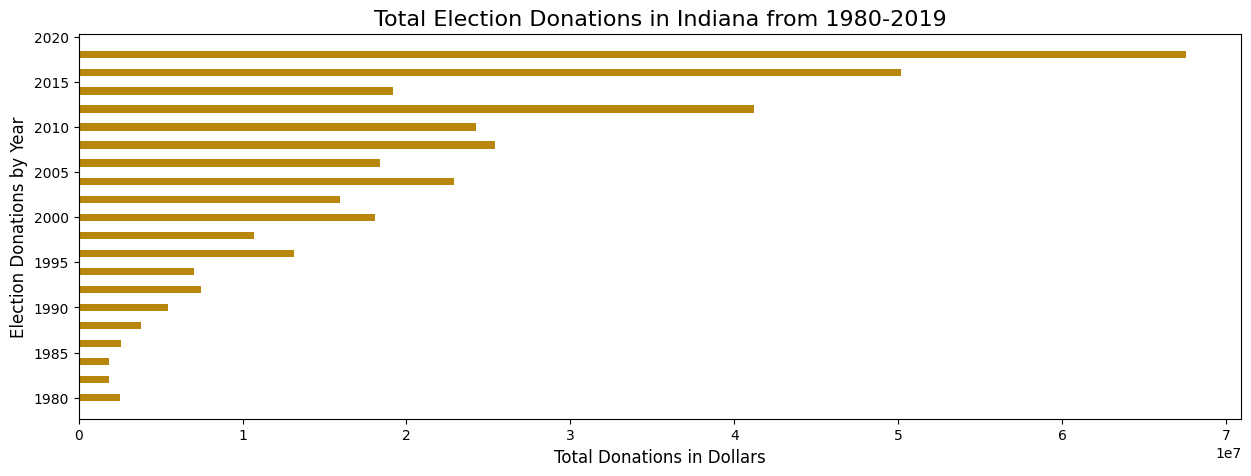

In [67]:
plt.figure(figsize=(15,5)) # <-- figsize=(15,5): Sets the width to 15 inches and height to 5 inches, ensuring a horizontal layout suitable for bar charts with longer labels.
plt.barh(range(1980,2019,2), myIndyTotal_donate, color='darkgoldenrod')
plt.xlabel("Total Donations in Dollars", fontsize=12) #"Total Donations in Dollars": Indicates that each bar corresponds to the total election donations transaction amounts in Indiana.
plt.ylabel("Election Donations by Year", fontsize=12) #Election Donations by Year: Indicates that the y-axis represents the total amount of election transaction donations each year in the dataset.
plt.title("Total Election Donations in Indiana from 1980-2019", fontsize=16) #Election Donations by Year: Describes what is being visualized (the frequency/total donation transaction amounts in Iniana per year in the dataset).
plt.show() #Display Chart - Without this line, no visualization will appear when running scripts in some environments (e.g., Jupyter Notebook or standalone Python scripts).

<BarContainer object of 20 artists>

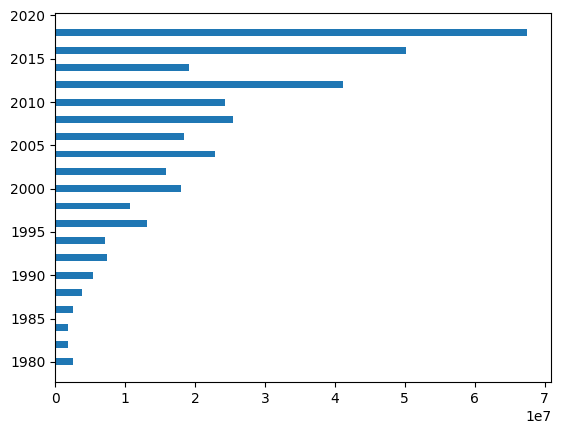

In [66]:
plt.barh(range(1980,2019,2), myIndyTotal_donate)

In [68]:
def myTopdonations (myyear: int) -> int:
    """
    The myTopdonations function takes a year as the input, and returns the amount of money donated from each state during that year.

    Args:
    myyear (str): This is a year as the input

    Returns:
    myvalue (int): This is the amount of money donated from each state during that year.
    """
    myDonate = pd.read_csv("/anvil/projects/tdm/data/election/itcont" + str(myyear) + ".txt", header=None, sep='|', usecols=[9,14], dtype={14: 'int64'}, encoding='Windows-1252') # - Reads donation data for the specified year with transaction amounts explicitly cast as integers (dtype={14: 'int64'}) 
    myDonate.columns = ["STATE", "TRANSACTION_AMT"]
    myState_Donate = myDonate.groupby('STATE')['TRANSACTION_AMT'].sum()
    return myState_Donate

In [ ]:
# Returns calculated donation totals grouped by state for the given year

In [72]:
myTotaldonations = list(map(myTopdonations, range(1980,2019,2)))
pd.concat(myTotaldonations, axis=1).sum(axis=1)

STATE
01    1.814000e+03
AK    6.118033e+07
AL    2.715780e+08
AR    2.356484e+08
AS    3.842270e+05
AZ    4.768146e+08
BE    1.410700e+04
CA    4.822789e+09
CO    5.687302e+08
CT    7.868996e+08
CZ    9.500000e+02
DC    2.420819e+09
DE    8.059579e+07
EL    1.000000e+03
FL    2.097903e+09
GA    6.584502e+08
GU    3.971562e+06
HI    9.341467e+07
IA    1.756754e+08
ID    6.919602e+07
IL    1.568633e+09
IN    3.594108e+08
KS    2.223416e+08
KY    2.952531e+08
LA    3.709754e+08
MA    1.085497e+09
MD    7.844235e+08
ME    1.030500e+08
MI    7.174223e+08
MN    4.357478e+08
MO    4.970891e+08
MS    1.394455e+08
MT    8.357215e+07
NC    5.308700e+08
ND    4.964602e+07
NE    1.638327e+08
NH    1.310296e+08
NJ    9.230388e+08
NM    1.761114e+08
NV    6.343116e+08
NY    3.790392e+09
OH    8.969982e+08
OK    2.712736e+08
OR    2.370424e+08
PA    1.150426e+09
PR    6.716942e+07
RI    8.519924e+07
SC    2.159393e+08
SD    6.791224e+07
TN    4.882727e+08
TU    2.500000e+02
TX    2.619004e+09
UT    

In [ ]:
# Sorts states by total donations across all years and selects the top 10 contributors using .tail(10)

In [73]:
myTotal_10_donations = pd.concat(myTotaldonations, axis=1).sum(axis=1).sort_values().tail(10)

In [ ]:
# Creates a horizontal bar chart showing the top 10 donating states based on cumulative totals

<BarContainer object of 10 artists>

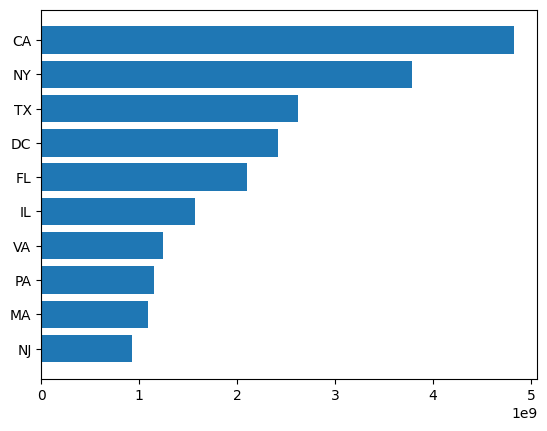

In [75]:
plt.barh(myTotal_10_donations.index, myTotal_10_donations)